# Weight Manipulation Red Teaming Linear

Copyright 2026, Battelle Energy Alliance, LLC, ALL RIGHTS RESERVED

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
os.chdir("../..")
from HelpingFunctions import ERCOTProcessor
from HelpingFunctions import WeatherProcessing
from HelpingFunctions import FeatureEngineering
from HelpingFunctions import ForecastingHelpers

import onnxruntime as ort
ort.set_default_logger_severity(4)

In [2]:
import os 
os.getcwd()

'/home/lambpc/AMARANTH/opensourcegridmodeling'

## Data Preprocessing for RT Data

In [3]:
full_df = pd.read_csv('ElectricityDemandAustinTX/LoadForecastingAttacks/full_data.csv', parse_dates=['time'], index_col=['time'])

In [4]:
hourly_res_norm = ForecastingHelpers.hourlyresiduals(full_df)

/home/lambpc/AMARANTH/opensourcegridmodeling/ElectricityDemandAustinTX/LoadForecastingAttacks/HelpingFunctions/ForecastingHelpers.py:74: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  hourly_res_norm['load'] = df_norm['load'].groupby(pd.Grouper(freq='M')).transform(lambda x: x - x.mean())


In [5]:
# train-validate-test split
train = hourly_res_norm[:'2014']
validate = hourly_res_norm['2015':'2016']
test = hourly_res_norm['2017':]

# setup training variables 
exog_tr = train.iloc[:,1:].values
ar_tr = train['load'].shift().bfill().values[:,None]
X_tr = np.hstack([ar_tr, exog_tr])
y_tr = train['load'].values

# setup validation variables
exog_val = validate.iloc[:,1:].values
y_val = validate['load'].values

# setup testing variables
exog_te = test.iloc[:,1:].values
ar_test = test['load'].shift().bfill().values[:,None]
y_test = test['load'].values
X_test = np.hstack([ar_test, exog_te])

# setup miscellaneous variables
yp_full = hourly_res_norm.loc[:'2016','load']
yp_val = hourly_res_norm.loc['2015':'2016','load']
yp_te = hourly_res_norm.loc['2017':,'load']
y_init_val = np.hstack([y_tr[-1], validate.iloc[167::168,0].values])
y_init_te = np.hstack([y_val[-1], test.iloc[167::168,0].values])

## Linear Regression

In [6]:
import onnx
onnx_model =  onnx.load("ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/linear_no_mapie.onnx")

In [31]:
import hashlib

res = hashlib.md5(b"ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/linear_no_mapie.onnx")
print(res.digest())

b'x<[u\x81F\x17\\\xb5\xe7\x8d\x1b\xe0BO/'


In [8]:
def forecast(session, exog, y_init, label_name, input_name):
    """given a trained model, exogenous features, and initial AR term, makes forecasting predictions"""
    yhat = []
    y_ci = []
    Xi_te = np.hstack([y_init, exog[0]])[None,:]
    for i in range(len(exog)-1):
        yhat_i = sess.run([label_name], {input_name: Xi_te.astype(np.double)})[0][0]
        yhat.append(yhat_i)
        Xi_te = np.hstack([yhat_i, exog[i+1]])[None,:]
    yhat_i = sess.run([label_name], {input_name: Xi_te.astype(np.double)})[0][0]
    yhat.append(yhat_i)
    return np.array(yhat)

def weekly_forecast(indexes, session, exog, y_init, label_name, input_name):
    """given a trained model exogenous features, and initial AR term, makes a series of 1-week-out forecasts"""
    yhat = []
    for i, yi in enumerate(y_init):
        exog_i = exog[168*i:168*(i+1),:]
        if exog_i.shape[0] < 1:
            break
        y_hat_i = forecast(session, exog_i, yi, label_name, input_name)
        yhat.append(y_hat_i)
    mapie_hat = pd.DataFrame(np.vstack(yhat).reshape(-1))
    return mapie_hat.values.ravel()

In [9]:
# Compute the prediction with onnxruntime.
import onnxruntime as rt

sess = rt.InferenceSession("ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/linear_no_mapie.onnx", providers=["CPUExecutionProvider"])
input_name = sess.get_inputs()[0].name
label_name = sess.get_outputs()[0].name
#pred_onx = sess.run([label_name], {input_name: exog_te})[0]

In [32]:
res = hashlib.md5(b"ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/linear_no_mapie.onnx")
print(res.digest())

b'x<[u\x81F\x17\\\xb5\xe7\x8d\x1b\xe0BO/'


In [10]:
preds_onx = weekly_forecast(yp_te.index, sess, exog_te, y_init_te, label_name, input_name)

In [11]:
# plotting testing
print('MAE:', ForecastingHelpers.compute_mae(y_test, preds_onx))

MAE: 0.06649123114844394


### Grab weights for Linear Regression

In [12]:
import onnx
onnx_model =  onnx.load("ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/linear_no_mapie.onnx")

In [13]:
weights = onnx_model.graph.initializer[0].ListFields()[3][1][:]

In [14]:
weights_df = pd.DataFrame(weights, index=full_df.columns, columns=["weights"])

In [15]:
weights_df.sort_values("weights", ascending=False)

,weights
load,9.387454e-01
snow,3.647535e-03
sin_hour,2.721396e-03
weekday,1.953546e-03
cloud,-5.204170e-18
humd,-6.013133e-05
tstorm,-6.506415e-05
clear,-9.119936e-04
rain,-1.215438e-03
fog,-1.455039e-03


Weights look to be generally between -1 and 1 for this model.

# Convert to Original Shape

In [16]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

load_min, load_max = full_df['load'].min(), full_df['load'].max()
temp_min, temp_max = full_df['temp'].min(), full_df['temp'].max()
wnsp_min, wnsp_max = full_df['wnsp'].min(), full_df['wnsp'].max()


# best hyperparameters from grid search
best_monthly_order = (1,1,1)
best_monthly_seas_order = (0,1,1,12)


# monthly average forecasts
monthly_norm = full_df['load'].resample('MS').mean().bfill()
train_m = monthly_norm[:'2016']
test_m = monthly_norm['2017':]
model_m = SARIMAX(train_m, order=best_monthly_order, seasonal_order=best_monthly_seas_order).fit()
forecast_m = model_m.get_forecast(steps=len(test_m))
pred_m_norm = pd.Series(forecast_m.predicted_mean, index=test_m.index)

# baseline hourly residual forecasts
idx = test.index[::168]
idx = idx.append(pd.DatetimeIndex(['2017-12-31 23']))
pred_base = pd.Series(np.hstack([y_init_te, yp_te.iloc[-1]]), index=idx)
pred_base = pred_base.resample('H').ffill().values

/home/lambpc/.conda/envs/AustinTXForecast/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/var/tmp/pbs.4906521.sawtoothpbs/ipykernel_35900/673366613.py:25: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  pred_base = pred_base.resample('H').ffill().values


In [17]:
# dataframe of montly forecasts
m_norm_df = pd.DataFrame({'m_norm':pred_m_norm, 'month':pred_m_norm.index.month, 'year':pred_m_norm.index.year})

lr_norm_df = pd.DataFrame({'h_norm':preds_onx, 'month':test.index.month, 'year':test.index.year})
pred_lr_norm_df = lr_norm_df.merge(m_norm_df, on=['month','year'])
pred_lr_norm = pd.Series((pred_lr_norm_df['m_norm'] + pred_lr_norm_df['h_norm']).values, index=test.index)
pred_lr = pred_lr_norm * (load_max - load_min) + load_min

# Downsample to a monthly basis to reduce KL and PSI sensitivity
sampled_pred = pred_lr.resample('MS').mean().bfill()

In [18]:
# Calculate the KL Divergence using SciPy's KL divergence modeling technique, where 
diverge = ForecastingHelpers.calculateKLDivergence(monthly_norm,sampled_pred)
med_drift_norm, high_drift = ForecastingHelpers.testDivergence(diverge, monthly_norm)
med_drift_norm

Timestamp('2020-09-01 00:00:00')

In [19]:
over_load_loc = sampled_pred.index.get_loc(med_drift_norm)
over_load_loc

44

In [20]:
over_load = sampled_pred.loc[med_drift_norm]
over_load

np.float64(0.3752374385246229)

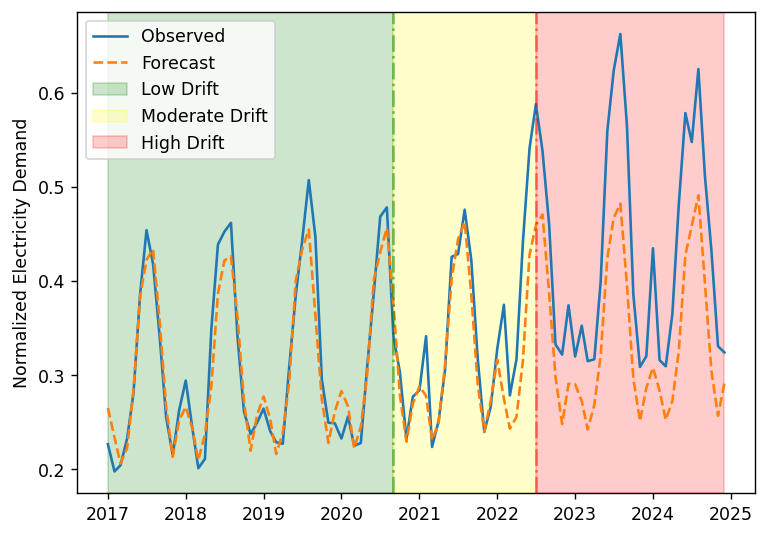

In [21]:
plt.plot(monthly_norm['2017':], label='Observed')
plt.plot(sampled_pred, label='Forecast', ls='--')
plt.axvline(x=med_drift_norm, color="green", alpha=0.5, linestyle="-.")
plt.axvline(x=high_drift, color="red", alpha=0.5, linestyle="-.")
plt.axvspan(sampled_pred.index[0],med_drift_norm, color='green', alpha=0.2, label="Low Drift")
plt.axvspan(med_drift_norm,high_drift, color='yellow', alpha=0.2, label="Moderate Drift")
plt.axvspan(high_drift,sampled_pred.index[-1], color='red', alpha=0.2, label="High Drift")
#plt.axvline(x=div, color="black", alpha=0.5, linestyle="--", label="Confidence Interval Drift")
plt.ylabel('Normalized Electricity Demand')
plt.legend();

In [22]:
print('MAE:', ForecastingHelpers.compute_mae(monthly_norm['2017':], sampled_pred))

MAE: 0.046058989642268656


In [23]:
sampled_pred.to_csv("ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/linear_results.csv")

## Perturbed version

In [57]:
import random
import time

onnx_model =  onnx.load("ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/linear_no_mapie.onnx")
cost_pos = {}

def determineScore(pert_onx, weights):
    # dataframe of montly forecasts
    m_norm_df = pd.DataFrame({'m_norm':pred_m_norm, 'month':pred_m_norm.index.month, 'year':pred_m_norm.index.year})
    lr_norm_df = pd.DataFrame({'h_norm':pert_onx, 'month':test.index.month, 'year':test.index.year})
    pred_lr_norm_df = lr_norm_df.merge(m_norm_df, on=['month','year'])
    pred_lr_norm = pd.Series((pred_lr_norm_df['m_norm'] + pred_lr_norm_df['h_norm']).values, index=test.index)
    pred_lr = pred_lr_norm * (load_max - load_min) + load_min

    # Downsample to a monthly basis to reduce KL and PSI sensitivity
    sampled_pred_pert = pred_lr.resample('MS').mean().bfill()

    score = sampled_pred_pert.loc[med_drift_norm]
    if score > over_load:
        return score, sampled_pred_pert
    else:
        return over_load, sampled_pred_pert
    

def gen_weights(dimensions, a, b):
    weights = []
    for i in range(dimensions):
        # Generate based on random uniform distribution
        weights.append(random.uniform(a, b))
    return weights

def writeTofile(weights):
    onnx_model.graph.initializer[0].ListFields()[3][1][:] = weights
    with open("ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/perturbed_linear.onnx", "wb") as f:
        f.write(onnx_model.SerializeToString())

def get_best_cost(cost_pos):
    # Order in best to worst cost
    sorted_cost = dict(sorted(cost_pos.items(), key=lambda item: item[1], reverse=True))
    return sorted_cost

        
        

In [68]:
res = hashlib.md5(b"ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/perturbed_linear.onnx")
print(res.hexdigest())

a028d0102161c436d309bf83b8d51699


In [60]:
weight = []
model = []
mae = np.inf
dist = np.inf

for i in range(10):
    onnx_model =  onnx.load("ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/linear_no_mapie.onnx")
    weights = gen_weights(13,-1,1)
    onnx_model.graph.initializer[0].ListFields()[3][1][:] = weights
    with open("ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/perturbed_linear.onnx", "wb") as f:
        f.write(onnx_model.SerializeToString())
    sess = rt.InferenceSession("ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/perturbed_linear.onnx", providers=["CPUExecutionProvider"])
    input_name = sess.get_inputs()[0].name
    label_name = sess.get_outputs()[0].name
    pert_onx = weekly_forecast(yp_te.index, sess, exog_te, y_init_te, label_name, input_name)

    score, sampled_pred_pert = determineScore(pert_onx, weights)
    if score != over_load:
        weight.append(weights)
        model.append(sampled_pred_pert)

for i in range(len(model)):
    mae_x = ForecastingHelpers.compute_mae(monthly_norm['2017':], model[i])
    diverge = ForecastingHelpers.calculateKLDivergence(monthly_norm,model[i])
    med_drift, high_drift = ForecastingHelpers.testDivergence(diverge, model[i])
    dist_x = np.linalg.norm(monthly_norm['2017':'2018'] - model[i]['2017':'2018'])
    if mae_x < mae and dist_x < dist:
        dist = dist_x
        mae = mae_x
        top_model = model[i]
        top_weights = weights[i]

In [69]:
# was b'\xa0(\xd0\x10!a\xc46\xd3\t\xbf\x83\xb8\xd5\x16\x99'
res = hashlib.md5(b"ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/perturbed_linear.onnx")
print(res.hexdigest())

#Does not change despite weights (and thus results) changing for the file. Implies the hash will not detect the changes to the file

a028d0102161c436d309bf83b8d51699


In [62]:
top_model.to_csv("ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/perturbed_linear_results.csv")

In [63]:
# Calculate the KL Divergence using SciPy's KL divergence modeling technique, where 
diverge = ForecastingHelpers.calculateKLDivergence(monthly_norm,top_model)
med_drift, high_drift = ForecastingHelpers.testDivergence(diverge, monthly_norm)
med_drift

Timestamp('2017-01-01 00:00:00')

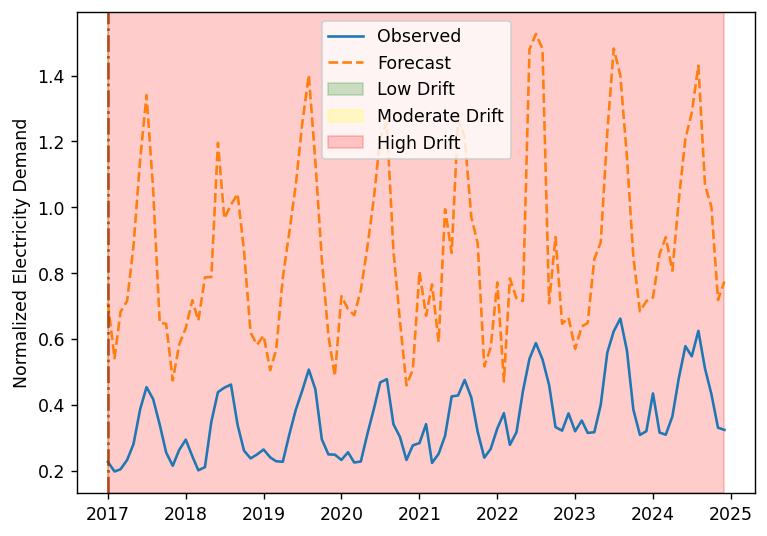

In [64]:
plt.plot(monthly_norm['2017':], label='Observed')
plt.plot(top_model, label='Forecast', ls='--')
plt.axvline(x=med_drift, color="green", alpha=0.5, linestyle="-.")
plt.axvline(x=high_drift, color="red", alpha=0.5, linestyle="-.")
plt.axvspan(top_model.index[0],med_drift, color='green', alpha=0.2, label="Low Drift")
plt.axvspan(med_drift,high_drift, color='yellow', alpha=0.2, label="Moderate Drift")
plt.axvspan(high_drift,top_model.index[-1], color='red', alpha=0.2, label="High Drift")
#plt.axvline(x=div, color="black", alpha=0.5, linestyle="--", label="Confidence Interval Drift")
plt.ylabel('Normalized Electricity Demand')
plt.legend();

In [65]:
ForecastingHelpers.compute_mae(monthly_norm['2017':], top_model)

np.float64(0.5108246829215656)